In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
from src.config import load_config
from src.runs.run_velocities import run
from src.features.value_surface import normalised_velocities, in_six_yard_box
from src.data_io.load import load_match
from src.data_io.transform import build_normalised

pd.set_option("display.width", 160)
cfg = load_config(ROOT / "config.yaml")
FIG = ROOT / "outputs" / "figures";

In [2]:
res_vels = run(cfg=cfg)  # loops every match in matches_dir, one in RAM at a time

Match ID: 1874553 | Mean speed : 2.59 m/s | Minimum speed: 0.00 m/s | Maximum speed: 12.64 m/s | Counting: 472180 | Time: 5.9s
Match ID: 1886347 | Mean speed : 2.64 m/s | Minimum speed: 0.00 m/s | Maximum speed: 11.59 m/s | Counting: 466285 | Time: 5.6s
Match ID: 1899585 | Mean speed : 2.52 m/s | Minimum speed: 0.00 m/s | Maximum speed: 12.13 m/s | Counting: 410078 | Time: 5.2s
Match ID: 1925299 | Mean speed : 2.46 m/s | Minimum speed: 0.00 m/s | Maximum speed: 12.81 m/s | Counting: 495299 | Time: 6.3s
Match ID: 1927964 | Mean speed : 2.33 m/s | Minimum speed: 0.00 m/s | Maximum speed: 12.75 m/s | Counting: 548837 | Time: 5.4s
Match ID: 1953632 | Mean speed : 2.44 m/s | Minimum speed: 0.00 m/s | Maximum speed: 11.08 m/s | Counting: 508148 | Time: 5.5s
Match ID: 1959846 | Mean speed : 2.55 m/s | Minimum speed: 0.00 m/s | Maximum speed: 12.16 m/s | Counting: 436910 | Time: 5.8s
Match ID: 1986691 | Mean speed : 2.42 m/s | Minimum speed: 0.00 m/s | Maximum speed: 12.20 m/s | Counting: 4557

In [3]:
# Fully separate feature: SG-smoothed velocities, gap-aware over detected-only runs.
# Needs one match's raw tracking (not the audit's concatenated alignment table).
vcfg = cfg["velocities"]
m0 = load_match(cfg["data"]["matches_dir"], 1874553)
frames0, tracking0 = build_normalised(m0)
norm_vels = normalised_velocities(m0, frames0, tracking0, fps=cfg["data"]["fps"],
                                  window_length=vcfg["window_length"],
                                  polyorder=vcfg["polyorder"],
                                  max_speed_mps=vcfg["max_speed_mps"])
norm_vels[["vx", "vy", "speed"]].describe()


,vx,vy,speed
count,472180.000000,472180.000000,472180.000000
mean,0.688321,0.019614,2.585957
std,2.237334,1.855948,1.495722
min,-8.653333,-8.288333,0.001667
25%,-0.731667,-1.198252,1.438240
50%,0.588333,0.028333,2.357562
75%,2.062327,1.231667,3.508022
max,12.322641,11.438485,12.637764


## Hypothesis: "V(x, y) is highest near the six-yard box"

I.e. passing options located in the six-yard box carry the most xThreat — not
a claim about player speed. Three checks, cheapest first:
1. **Raw sample comparison** — mean `xthreat` of `passing_option` events whose
   receiving location (`x_end`, `y_end`) falls inside a six-yard box vs. not,
   pooled across all matches (events only, no tracking needed).
2. **Distance-to-goal profile** — reuse `res_vels.surfaces_grid` (already
   computed by `run()` above, one `vxy(method="grid")` grid per match) and
   look at the n-weighted mean V by distance-to-goal band.
3. **Visual sanity check** — V(x, y) heatmap for one match with both
   six-yard boxes outlined.

Note: `build_normalised` always orients the team in possession toward +x, so
the only box that should ever light up is the *attacking* one — the defending
team's own box should stay near zero.


In [4]:
import numpy as np
from src.data_io.load import iter_matches, list_match_ids

# Check 1: raw samples, pooled across all matches. with_tracking=False - this
# only needs event columns, not the (slow) tracking file.
po_all = []
for m in iter_matches(cfg["data"]["matches_dir"], list_match_ids(cfg["data"]["matches_dir"]),
                      with_tracking=False):
    po = m.events[m.events.event_type == "passing_option"].dropna(subset=["x_end", "y_end", "xthreat"]).copy()
    po["in_six_yard_box"] = in_six_yard_box(po.x_end, po.y_end, m.pitch_length)
    po_all.append(po[["match_id", "in_six_yard_box", "xthreat"]])

po_all = pd.concat(po_all, ignore_index=True)
po_all.groupby("in_six_yard_box").xthreat.agg(["mean", "median", "count"])


,mean,median,count
in_six_yard_box,,,
False,0.010489,0.0023,48251
True,0.125538,0.0803,55


In [5]:
# Check 2: distance-to-goal profile from res_vels.surfaces_grid - now ONE
# pooled grid over all matches (run_velocities.run concatenates events, not
# per-match surfaces, and sizes the grid to the largest pitch in the set), so
# n is a genuine total sample count per cell and no cross-match reweighting
# is needed here.
L_ref = 105.0  # standard pitch, only used to define the distance bands
surf = res_vels.surfaces_grid
surf = surf[surf.n > 0].copy()
surf["dist_to_goal"] = L_ref / 2 - surf.x
surf = surf[surf.dist_to_goal >= 0]  # drop cells behind the goal line
bins = np.arange(0, L_ref / 2 + 5, 5)

surf["dist_bin"] = pd.cut(surf.dist_to_goal, bins)
surf.groupby("dist_bin", observed=True).apply(
    lambda g: pd.Series({"V_weighted_mean": np.average(g.V, weights=g.n), "n_total": g.n.sum()}))


,V_weighted_mean,n_total
dist_bin,,
"(0.0, 5.0]",0.094341,83.0
"(5.0, 10.0]",0.082855,622.0
"(10.0, 15.0]",0.055521,2341.0
"(15.0, 20.0]",0.036367,1977.0
"(20.0, 25.0]",0.023375,3119.0
"(25.0, 30.0]",0.016373,2242.0
"(30.0, 35.0]",0.012056,3539.0
"(35.0, 40.0]",0.008633,2489.0
"(40.0, 45.0]",0.006885,4057.0


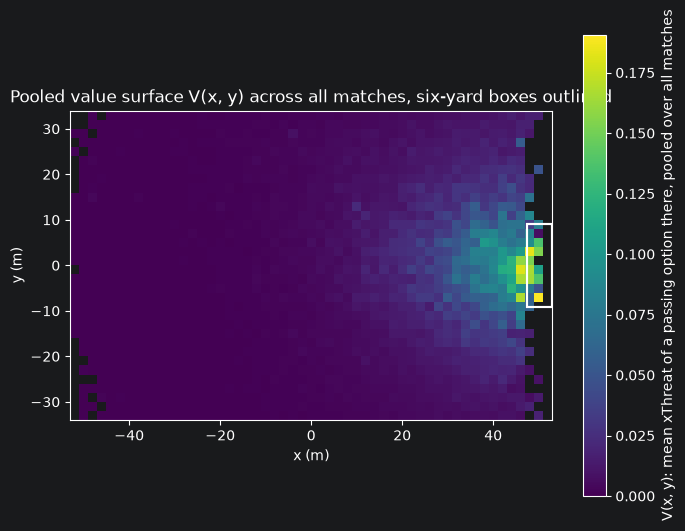

In [6]:
# Check 3: visual sanity check on the POOLED surface (res_vels.surfaces_grid,
# all matches, one shared grid) - only the attacking (+x) box should light up,
# since build_normalised always orients the team in possession toward +x.
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from src.data_io.load import iter_matches, list_match_ids

# Same "largest pitch in the set" sizing run() used, recomputed here (not
# hardcoded) so this stays correct if the match set changes.
L = max(m.pitch_length for m in iter_matches(cfg["data"]["matches_dir"],
                                             list_match_ids(cfg["data"]["matches_dir"]), with_tracking=False))
grid = res_vels.surfaces_grid.pivot(index="y", columns="x", values="V")

fig, ax = plt.subplots(figsize=(7, 5))
mesh = ax.pcolormesh(grid.columns, grid.index, grid.to_numpy(), shading="nearest", cmap="viridis")
fig.colorbar(mesh, ax=ax, label="V(x, y): mean xThreat of a passing option there, pooled over all matches")
for sign in (1, -1):
    ax.add_patch(patches.Rectangle((L / 2 - 5.5, -9.16), 5.5, 18.32,
                                   fill=False, edgecolor="white", linewidth=1.5))
ax.set_xlabel("x (m)");
ax.set_ylabel("y (m)");
ax.set_aspect("equal")
ax.set_title("Pooled value surface V(x, y) across all matches, six-yard boxes outlined")
plt.tight_layout()
plt.show()
fig.savefig(FIG / "02_value_surface.png", dpi=200, bbox_inches="tight")
